In [1]:
import NNSA

# List of available models:

In [2]:
NNSA.available_models()

BaSTIModel (http://basti-iac.oa-abruzzo.inaf.it/)
BaSTI_HSTModel (http://basti-iac.oa-abruzzo.inaf.it/)
PARSECModel (https://stev.oapd.inaf.it/PARSEC/)
MISTModel (https://waps.cfa.harvard.edu/MIST/)
SYCLISTModel (https://www.unige.ch/sciences/astro/evolution/en/database/syclist)
DartmouthModel (https://rcweb.dartmouth.edu/stellar/)
YaPSIModel (http://www.astro.yale.edu/yapsi/)


# Load BaSTI model:
#### By default, the age models use sklearn to run the neural networks. If you do not have it installed, or don't want to use it, you can pass the argument 'use_sklearn=False' to switch to a numpy version. Be aware though, in this mode it becomes significantly slower once you run the models on more than ~100 stars.

In [3]:
age_model = NNSA.BaSTIModel()
#age_model = NNSA.BaSTIModel(use_sklearn=False)

# Estimate the age of a single star using [M/H],mag,col:
#### To estimate the age of a star, use the ages_prediction() method, and pass it a metallicity met, magnitude mag and color col. Be aware with only these values provided, the return value is a np.array of shape (1,1). The reason will be clear if you check later uses. 

In [4]:
age_model.ages_prediction(met=0.0,mag=4.0,col=1.0)

array([[13.89808636]])

#### You can use the check_domain() method to verify that the star is within the bounds of the isochrones points used for training the neural networks. The function only checks for this in the HR Diagram, so you pass it a metallicity met, magnitude mag and color col.

In [5]:
age_model.check_domain(met=0.0,mag=4.0,col=1.0)

array([ True])

# Estimate the age of a single star using [M/H],mag,col,GBP & GRP:
#### If you are using Gaia magnitudes and colors, you can also pass the red GRP and blue GBP magnitudes separately as additional inputs. This generally results in better estimations.

In [5]:
age_model.ages_prediction(met=0.0,mag=2.0,col=1.0,GBP=2.0,GRP=1.0)

array([[1.38048182]])

# Estimate the age of multiple stars:
#### If you pass lists of values of size N as inputs instead of single values, the return value of the ages_prediction() method will be a np.array of shape (N,1). Again, the reason for the 2D shape will be clear by checking later uses.

In [ ]:
age_model.ages_prediction(met=[0.0,-1.0],mag=[2.0,3.0],col=[1.0,0.5])

array([[1.6267248 ],
       [5.99103612]])

In [ ]:
age_model.ages_prediction(met=[0.0,-1.0],mag=[2.0,3.0],col=[1.0,0.5],GBP=[2.0,1.0],GRP=[1.0,0.5])

array([[1.38048182],
       [2.16979408]])

#### You can also check if the stars are within the training domain all at once by passing lists of metallicity met, magnitude mag & col values col.

In [ ]:
age_model.check_domain(met=[0.0,-1.0],mag=[2.0,3.0],col=[1.0,0.5])

array([ True,  True])

#### That way, you can crossmatch both outputs to only keep stars whose age estimates we can reliably trust:

In [6]:
met = [0.0,-1.0,-2.0,-3.0]
mag = [2.0,3.0,3.0,3.0]
col = [1.0,0.5,0.5,0.5]
GBP = [2.0,1.0,1.0,1.0]
GRP = [1.0,0.5,0.5,0.5]
ages = age_model.ages_prediction(met=met,mag=mag,col=col,GBP=GBP,GRP=GRP)
print(ages)
outside_domain = age_model.check_domain(met=met,mag=mag,col=col)
print(outside_domain)
ages = ages[outside_domain]
print(ages)

100%|██████████| 4/4 [00:00<00:00, 4415.06it/s]

[[1.38048182]
 [2.16979408]
 [2.88745321]
 [3.4155044 ]]
[ True  True  True False]
[[1.38048182]
 [2.16979408]
 [2.88745321]]


# Estimate the age of a single star with n=10 Monte Carlo realisations using uncertainties:
#### If you have uncertainty values for a star, you can pass them to the ages_prediction() method by adding values for emet, emag & ecol. The idea is that multiple age predictions will be made by offsetting the star's metallicity met, magnitude mag & col col by adding a random gaussian offset of width (emet,emag,ecol). The number of realisations made is controlled by the parameter n. The output of the method will then be a np.array of shape (1,n).

In [7]:
age_model.ages_prediction(met=0.0,mag=2.0,col=1.0,emet=0.1,emag=0.1,ecol=0.1,n=10)

100%|██████████| 1/1 [00:00<00:00, 1261.07it/s]


array([[1.65162087, 1.46657526, 1.81940265, 1.63497839, 1.59219373,
        1.44250983, 2.04042885, 2.13728581, 1.57928341, 1.88275876]])

#### Once the ages have been predicted for each star n times, you can call statistical methods model.mean_ages(), model.median_ages(), model.mode_ages() and model.std_ages()

In [8]:
print(age_model.mean_ages())
print(age_model.median_ages())
print(age_model.mode_ages())
print(age_model.std_ages())

[1.72470376]
[1.64329963]
[1.63087219]
[0.22410199]


# Estimate the age of multiple stars with n=10 Monte Carlo realisations using uncertainties:
#### Finally, you can combine multiple (N) stars age estimations and added uncertainties, with n Monte Carlo realisations. The output of the ages_prediction() method will then be a np.array of shape (N,n). A value of n=100 seems to be a good middle ground between speed and accurate predictions. If the number of stars is low, n>=1000 gives enough realisations to draw a PDF.

In [9]:
age_model.ages_prediction(met=[0.0,-1.0],mag=[2.0,3.0],col=[1.0,0.5],emet=[0.1,0.1],emag=[0.1,0.1],ecol=[0.1,0.1],n=10)

100%|██████████| 2/2 [00:00<00:00, 799.68it/s]


array([[ 1.99718341,  1.71588737,  1.83287199,  1.61047087,  2.42897079,
        13.48489683,  1.88953732,  1.86428259,  2.05914279,  2.77580077],
       [ 6.55430862,  4.80571195,  4.74555477,  4.18257434,  7.72159335,
         6.67287718,  8.8318598 ,  9.05052799,  2.80676163,  6.64025183]])

In [8]:
print(age_model.mean_ages())
print(age_model.median_ages())
print(age_model.mode_ages())
print(age_model.std_ages())

[3.063641   5.46175466]
[1.74420579 5.60148992]
[1.65 6.65]
[3.60913347 1.2278143 ]


# BaSTI HST test:

100%|██████████| 1/1 [00:00<00:00, 136.04it/s]


(0.0, 40.0)

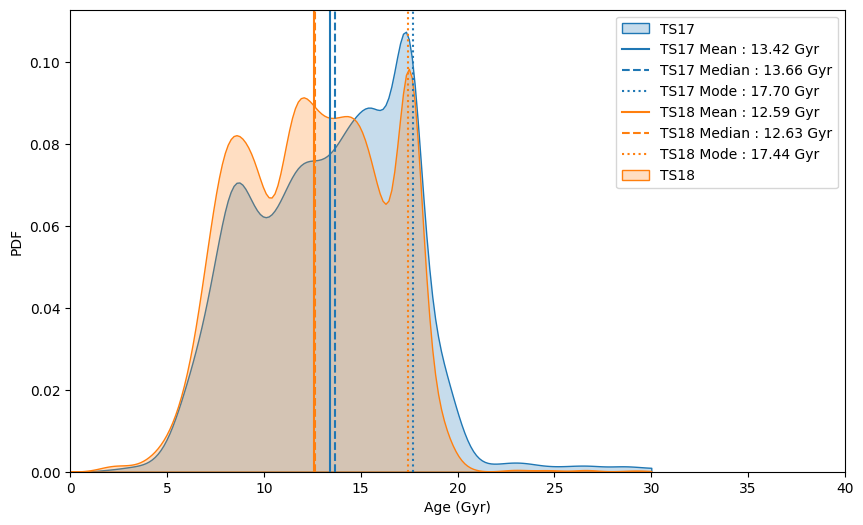

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

age_model = NNSA.BaSTI_HSTModel()

fig,ax = plt.subplots(1,1,figsize=(10,6))
age_model.ages_prediction(met=-2.22,mag=3.41,col=0.43,emet=0.11,emag=0.06,ecol=0.06,n=10_000)
sns.kdeplot(age_model.age_predictions[0],clip=(0,30),fill=True,label='TS17')
mean_age = age_model.mean_ages()[0]
plt.axvline(mean_age,ls='-',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0],label='TS17 Mean : {:.2f} Gyr'.format(mean_age))
median_age = age_model.median_ages()[0]
plt.axvline(median_age,ls='--',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0],label='TS17 Median : {:.2f} Gyr'.format(median_age))
mode_age = age_model.mode_ages()[0]
plt.axvline(mode_age,ls=':',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0],label='TS17 Mode : {:.2f} Gyr'.format(mode_age))
age_model.ages_prediction(met=-2.22,mag=3.5,col=0.42,emet=0.11,emag=0.05,ecol=0.05,n=10_000)
mean_age = age_model.mean_ages()[0]
plt.axvline(mean_age,ls='-',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1],label='TS18 Mean : {:.2f} Gyr'.format(mean_age))
median_age = age_model.median_ages()[0]
plt.axvline(median_age,ls='--',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1],label='TS18 Median : {:.2f} Gyr'.format(median_age))
mode_age = age_model.mode_ages()[0]
plt.axvline(mode_age,ls=':',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1],label='TS18 Mode : {:.2f} Gyr'.format(mode_age))
sns.kdeplot(age_model.age_predictions[0],clip=(0,30),fill=True,label='TS18')
plt.legend()
plt.xlabel('Age (Gyr)')
plt.ylabel('PDF')
plt.xlim(0,40)